# Exploratory Data Analysis — Drowsiness Detection Dataset


## 1. Setup

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import random
from collections import defaultdict
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from preprocessing import detect_and_crop_face, annotate_image

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})

DATASET_DIR = Path("dataset/train")
CLASS_NAMES = ["drowsy", "notdrowsy"]
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
RANDOM_SEED = 42
SAMPLE_SIZE = 800          # images per class for dimension/brightness stats
FACE_SAMPLE_SIZE = 200     # images per class for face-detection check

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

2026-07-16 15:40:06.337814: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[ WARN:0@9.728] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now


## 2. Dataset Structure & Class Distribution

In [2]:
def collect_image_paths(root: Path) -> dict[str, list[Path]]:
    paths_by_class: dict[str, list[Path]] = {}
    for class_dir in sorted(root.iterdir()):
        if not class_dir.is_dir():
            continue
        images = [
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS
        ]
        paths_by_class[class_dir.name] = sorted(images)
    return paths_by_class

paths_by_class = collect_image_paths(DATASET_DIR)
counts = {cls: len(paths) for cls, paths in paths_by_class.items()}
total_images = sum(counts.values())

print(f"Dataset root : {DATASET_DIR.resolve()}")
print(f"Classes found: {list(paths_by_class.keys())}")
print(f"Total images : {total_images:,}")
print()
for cls in sorted(counts):
    pct = 100 * counts[cls] / total_images
    print(f"  {cls:12s} : {counts[cls]:>6,}  ({pct:.1f}%)")

Dataset root : /home/nyax/code/drowsiness-detection/dataset/train
Classes found: ['drowsy', 'notdrowsy']
Total images : 66,521

  drowsy       : 36,030  (54.2%)
  notdrowsy    : 30,491  (45.8%)


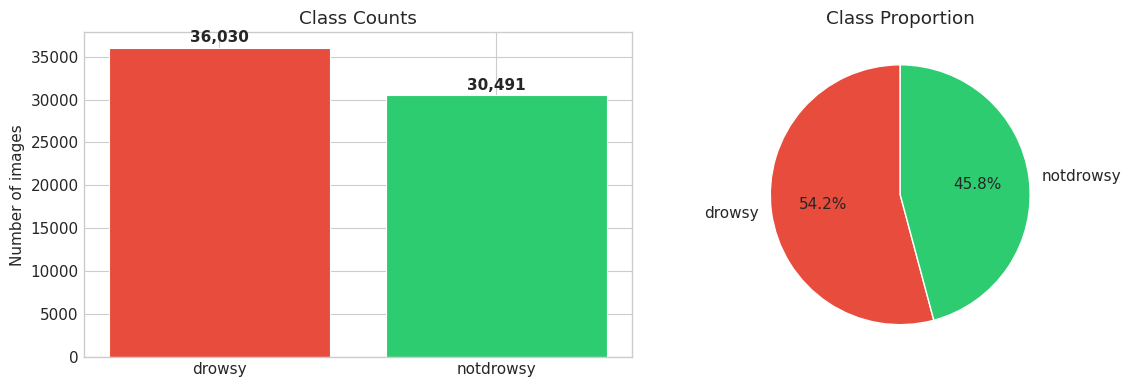

Class imbalance ratio (majority / minority): 1.18:1


In [3]:
labels = list(counts.keys())
values = [counts[c] for c in labels]
colors = ["#e74c3c", "#2ecc71"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Number of images")
for i, v in enumerate(values):
    axes[0].text(i, v + total_images * 0.01, f"{v:,}", ha="center", fontweight="bold")
axes[1].pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.show()


ratio = max(values) / min(values)
print(f"Class imbalance ratio (majority / minority): {ratio:.2f}:1")

## 3. File Size Distribution

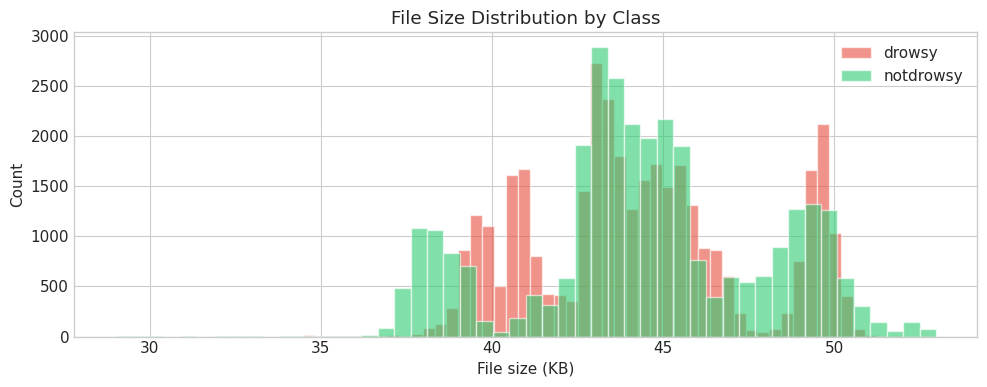

drowsy       — mean:   44.3 KB | median:   43.9 KB | std:    3.2 KB
notdrowsy    — mean:   44.5 KB | median:   44.3 KB | std:    3.5 KB


In [4]:
file_sizes_kb: dict[str, list[float]] = defaultdict(list)

for cls, paths in paths_by_class.items():
    for p in paths:
        file_sizes_kb[cls].append(p.stat().st_size / 1024)

fig, ax = plt.subplots(figsize=(10, 4))
for cls, color in zip(labels, colors):
    ax.hist(
        file_sizes_kb[cls],
        bins=50,
        alpha=0.6,
        label=cls,
        color=color,
        edgecolor="white",
    )

ax.set_xlabel("File size (KB)")
ax.set_ylabel("Count")
ax.set_title("File Size Distribution by Class")
ax.legend()
plt.tight_layout()
plt.show()

for cls in labels:
    sizes = np.array(file_sizes_kb[cls])
    print(
        f"{cls:12s} — mean: {sizes.mean():6.1f} KB | "
        f"median: {np.median(sizes):6.1f} KB | "
        f"std: {sizes.std():6.1f} KB"
    )

## 4. Image Dimensions & Aspect Ratio



Corrupt / unreadable images in sample:
  drowsy: 0
  notdrowsy: 0


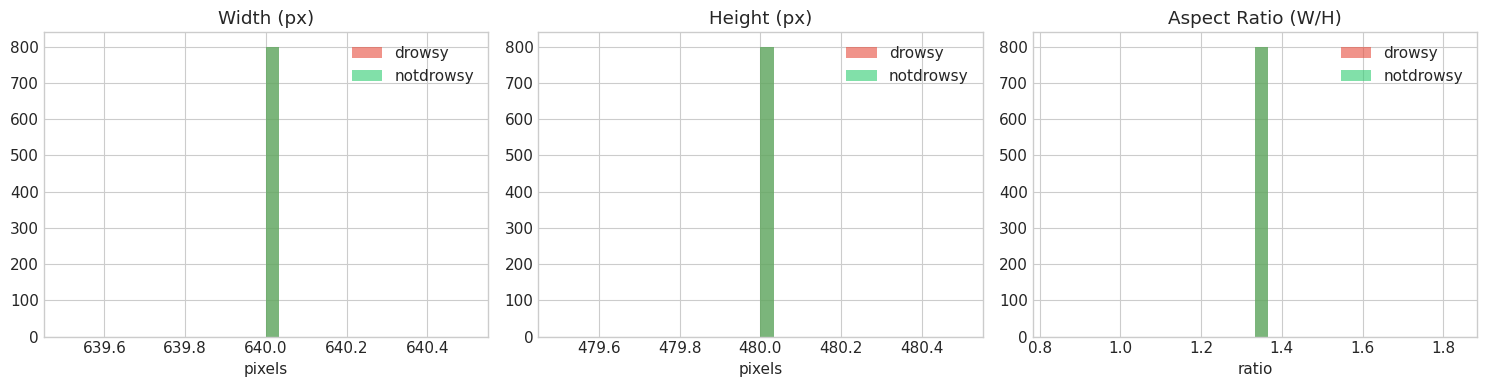

drowsy       — W: 640±0 | H: 480±0 | AR: 1.33±0.00
notdrowsy    — W: 640±0 | H: 480±0 | AR: 1.33±0.00


In [5]:
def sample_paths(paths: list[Path], n: int) -> list[Path]:
    if len(paths) <= n:
        return paths
    return random.sample(paths, n)

def read_image_rgb(path: Path) -> np.ndarray | None:
    bgr = cv2.imread(str(path))
    if bgr is None:
        return None
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

widths: dict[str, list[int]] = defaultdict(list)
heights: dict[str, list[int]] = defaultdict(list)
aspects: dict[str, list[float]] = defaultdict(list)
failed_reads: dict[str, int] = defaultdict(int)

for cls, paths in paths_by_class.items():
    for p in sample_paths(paths, SAMPLE_SIZE):
        img = read_image_rgb(p)
        if img is None:
            failed_reads[cls] += 1
            continue
        h, w = img.shape[:2]
        widths[cls].append(w)
        heights[cls].append(h)
        aspects[cls].append(w / h)

print("Corrupt / unreadable images in sample:")
for cls in labels:
    print(f"  {cls}: {failed_reads[cls]}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls, color in zip(labels, colors):
    axes[0].hist(widths[cls], bins=30, alpha=0.6, label=cls, color=color)
    axes[1].hist(heights[cls], bins=30, alpha=0.6, label=cls, color=color)
    axes[2].hist(aspects[cls], bins=30, alpha=0.6, label=cls, color=color)

axes[0].set_title("Width (px)");  axes[0].set_xlabel("pixels")
axes[1].set_title("Height (px)"); axes[1].set_xlabel("pixels")
axes[2].set_title("Aspect Ratio (W/H)"); axes[2].set_xlabel("ratio")
for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

for cls in labels:
    print(
        f"{cls:12s} — W: {np.mean(widths[cls]):.0f}±{np.std(widths[cls]):.0f} | "
        f"H: {np.mean(heights[cls]):.0f}±{np.std(heights[cls]):.0f} | "
        f"AR: {np.mean(aspects[cls]):.2f}±{np.std(aspects[cls]):.2f}"
    )

## 5. Brightness & Contrast (Grayscale)



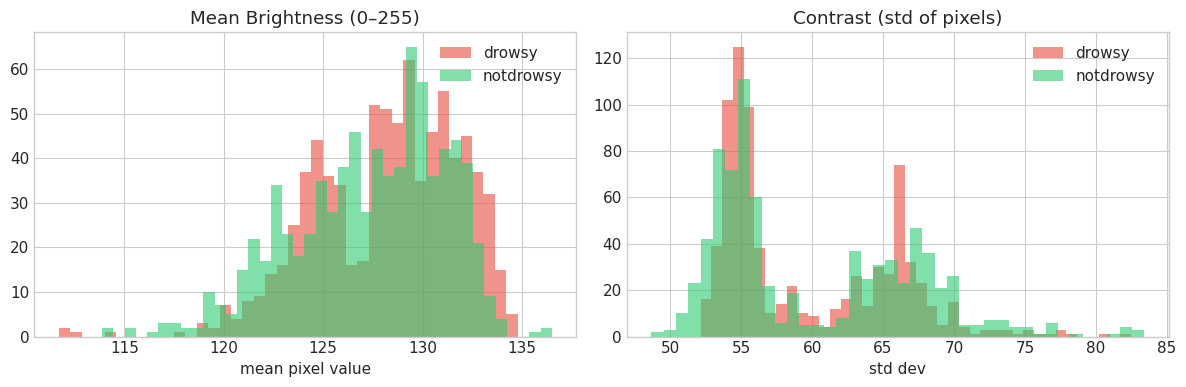

drowsy       — brightness: 128.2±3.6 | contrast: 59.6±6.0
notdrowsy    — brightness: 127.4±3.8 | contrast: 60.1±7.0


In [6]:
mean_brightness: dict[str, list[float]] = defaultdict(list)
std_brightness: dict[str, list[float]] = defaultdict(list)

for cls, paths in paths_by_class.items():
    for p in sample_paths(paths, SAMPLE_SIZE):
        img = read_image_rgb(p)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mean_brightness[cls].append(gray.mean())
        std_brightness[cls].append(gray.std())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, color in zip(labels, colors):
    axes[0].hist(mean_brightness[cls], bins=40, alpha=0.6, label=cls, color=color)
    axes[1].hist(std_brightness[cls], bins=40, alpha=0.6, label=cls, color=color)

axes[0].set_title("Mean Brightness (0–255)"); axes[0].set_xlabel("mean pixel value")
axes[1].set_title("Contrast (std of pixels)"); axes[1].set_xlabel("std dev")
for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

for cls in labels:
    print(
        f"{cls:12s} — brightness: {np.mean(mean_brightness[cls]):.1f}±{np.std(mean_brightness[cls]):.1f} | "
        f"contrast: {np.mean(std_brightness[cls]):.1f}±{np.std(std_brightness[cls]):.1f}"
    )

## 6. Sample Gallery

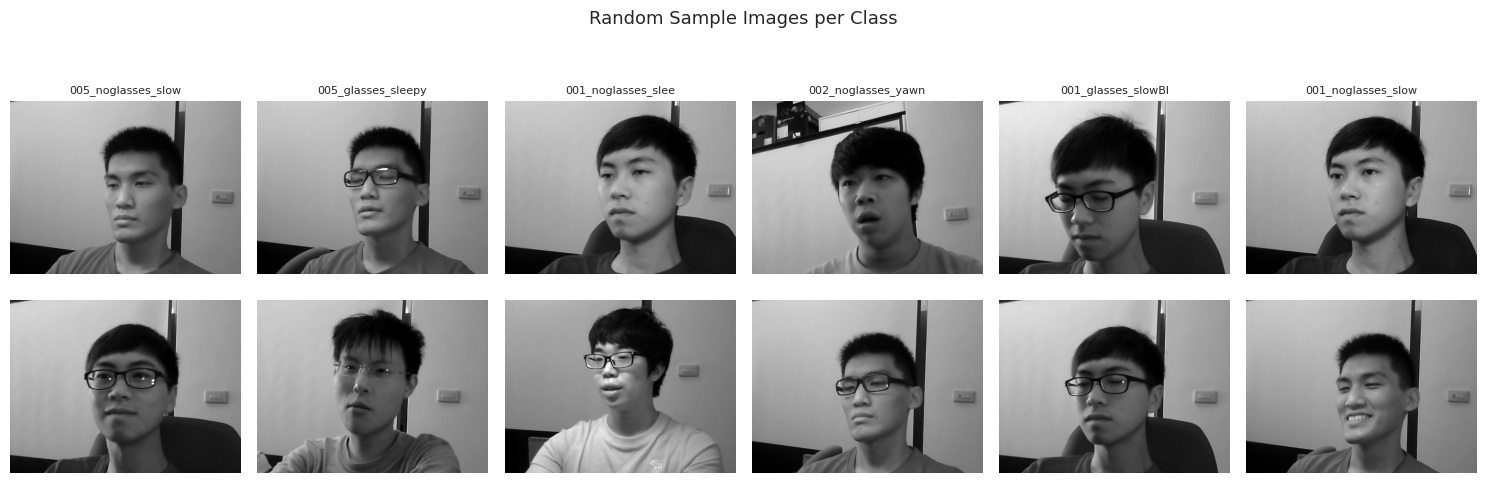

In [7]:
N_SAMPLES = 6

fig, axes = plt.subplots(len(labels), N_SAMPLES, figsize=(2.5 * N_SAMPLES, 2.5 * len(labels)))
if len(labels) == 1:
    axes = np.array([axes])

for row, cls in enumerate(labels):
    samples = sample_paths(paths_by_class[cls], N_SAMPLES)
    for col, path in enumerate(samples):
        img = read_image_rgb(path)
        ax = axes[row, col]
        if img is not None:
            ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls, fontsize=12, fontweight="bold")
        if row == 0:
            ax.set_title(path.name[:18], fontsize=8)

plt.suptitle("Random Sample Images per Class", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Face Detection Coverage


drowsy       — face detected: 100.0%  (200/200)
notdrowsy    — face detected: 99.5%  (199/200)


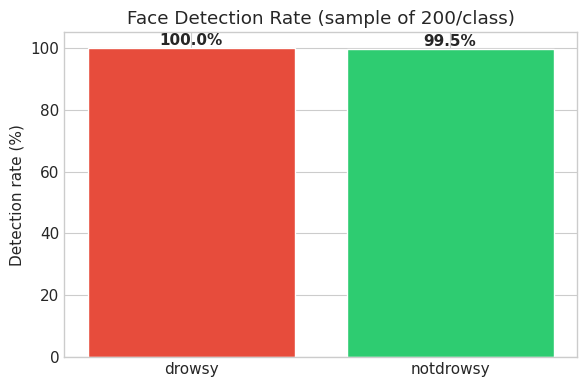

In [8]:
face_detected: dict[str, list[bool]] = defaultdict(list)

for cls, paths in paths_by_class.items():
    for p in sample_paths(paths, FACE_SAMPLE_SIZE):
        img = read_image_rgb(p)
        if img is None:
            continue
        _, bbox = annotate_image(img)
        face_detected[cls].append(bbox is not None)

fig, ax = plt.subplots(figsize=(6, 4))
det_rates = []
for cls in labels:
    rate = 100 * np.mean(face_detected[cls])
    det_rates.append(rate)
    print(f"{cls:12s} — face detected: {rate:.1f}%  ({sum(face_detected[cls])}/{len(face_detected[cls])})")

bars = ax.bar(labels, det_rates, color=colors, edgecolor="white")
ax.set_ylim(0, 105)
ax.set_ylabel("Detection rate (%)")
ax.set_title(f"Face Detection Rate (sample of {FACE_SAMPLE_SIZE}/class)")
for bar, rate in zip(bars, det_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 1, f"{rate:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Preprocessing Pipeline Preview


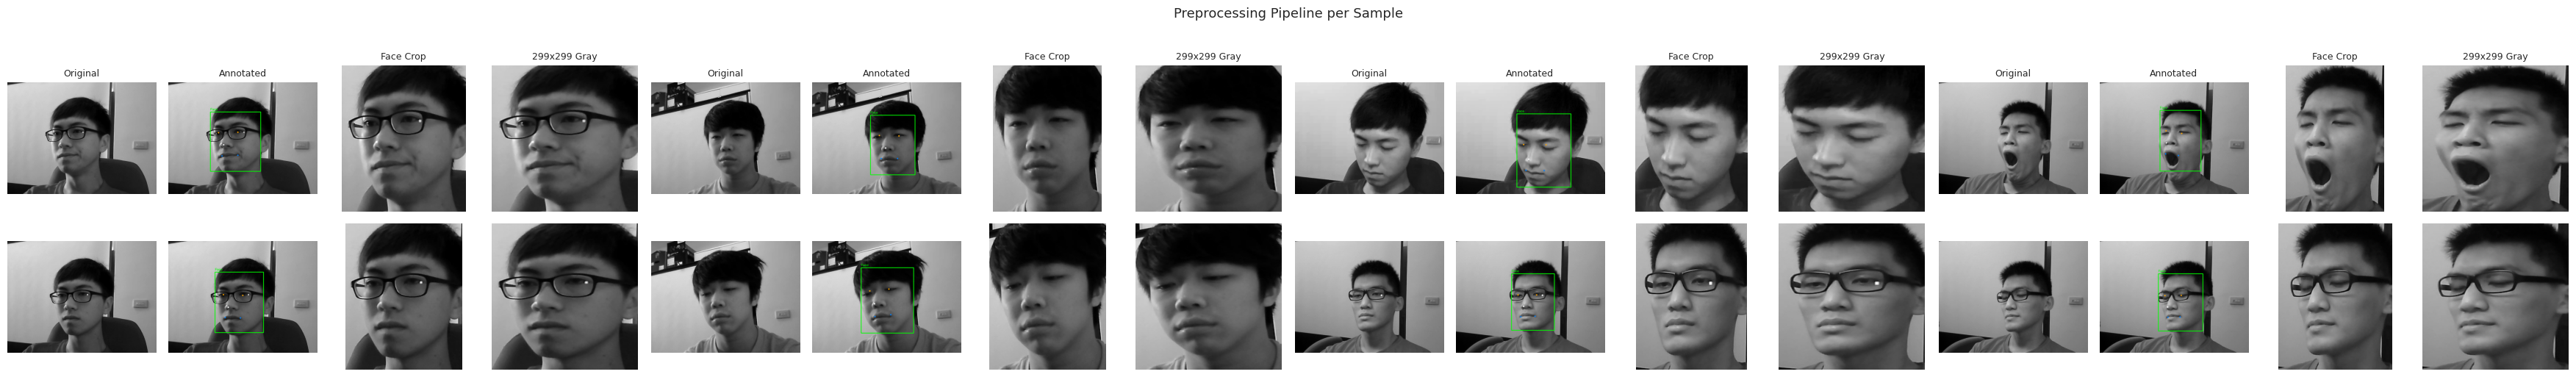

In [14]:
IMG_WIDTH, IMG_HEIGHT = 299, 299
N_PREVIEW = 4

fig, axes = plt.subplots(len(labels), N_PREVIEW * 4, figsize=(2.2 * N_PREVIEW * 4, 2.5 * len(labels)))
step_titles = ["Original", "Annotated", "Face Crop", "299x299 Gray"]

for row, cls in enumerate(labels):
    samples = sample_paths(paths_by_class[cls], N_PREVIEW)
    for col, path in enumerate(samples):
        img = read_image_rgb(path)
        if img is None:
            continue

        annotated, _ = annotate_image(img)
        cropped, _ = detect_and_crop_face(img)
        resized = cv2.resize(cropped, (IMG_WIDTH, IMG_HEIGHT))
        gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
        gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

        stages = [img, annotated, cropped, gray_rgb]
        for step, stage_img in enumerate(stages):
            ax = axes[row, col * 4 + step]
            ax.imshow(stage_img)
            ax.axis("off")
            if row == 0:
                ax.set_title(step_titles[step], fontsize=9)
            if step == 0 and col == 0:
                ax.set_ylabel(cls, fontsize=11, fontweight="bold")

plt.suptitle("Preprocessing Pipeline per Sample", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 9. Simulated Train / Validation Split


Simulated 80/20 split on 66,521 images:
  Training  : 53,217  (80.0%)
  Validation: 13,304  (20.0%)

  drowsy       — train: 28,824 | val: 7,206
  notdrowsy    — train: 24,393 | val: 6,098


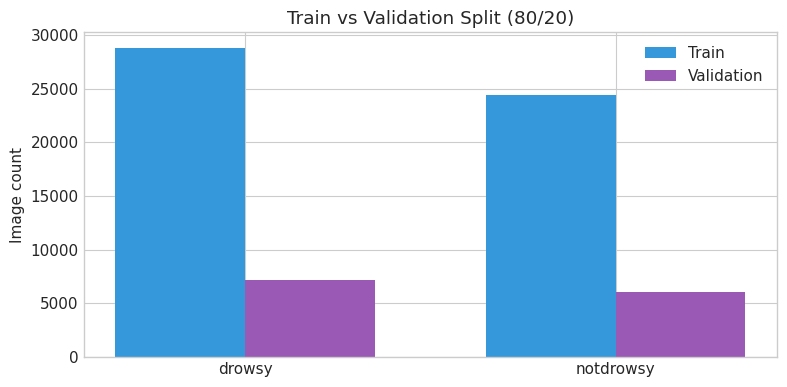

In [10]:
VAL_SPLIT = 0.2

split_summary = {}
for cls, n in counts.items():
    val_n = int(round(n * VAL_SPLIT))
    train_n = n - val_n
    split_summary[cls] = {"train": train_n, "val": val_n}

train_total = sum(s["train"] for s in split_summary.values())
val_total = sum(s["val"] for s in split_summary.values())

print(f"Simulated 80/20 split on {total_images:,} images:")
print(f"  Training  : {train_total:,}  ({100*train_total/total_images:.1f}%)")
print(f"  Validation: {val_total:,}  ({100*val_total/total_images:.1f}%)")
print()
for cls in labels:
    s = split_summary[cls]
    print(f"  {cls:12s} — train: {s['train']:>6,} | val: {s['val']:>5,}")

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, [split_summary[c]["train"] for c in labels], width, label="Train", color="#3498db")
ax.bar(x + width/2, [split_summary[c]["val"] for c in labels], width, label="Validation", color="#9b59b6")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Image count")
ax.set_title("Train vs Validation Split (80/20)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Data Augmentation Preview



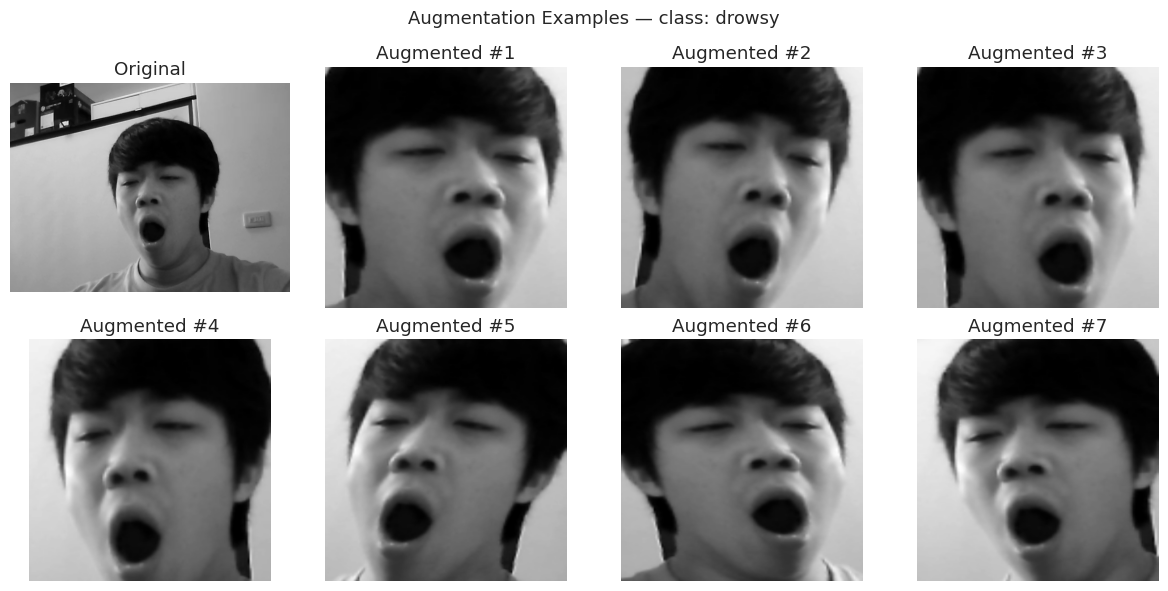

In [11]:
from tf_keras.preprocessing.image import ImageDataGenerator
from preprocessing import preprocessing_function

aug_datagen = ImageDataGenerator(
    preprocessing_function=preprocessing_function,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
)

preview_cls = labels[0]
preview_path = sample_paths(paths_by_class[preview_cls], 1)[0]
preview_img = read_image_rgb(preview_path)
preview_img_resized = cv2.resize(preview_img, (299, 299))
preview_batch = np.expand_dims(preview_img_resized, axis=0)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes[0, 0].imshow(preview_img)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

aug_iter = aug_datagen.flow(preview_batch, batch_size=1)
for i in range(1, 8):
    aug_img = next(aug_iter)[0]
    display = np.clip((aug_img - aug_img.min()) / (aug_img.max() - aug_img.min() + 1e-8), 0, 1)
    ax = axes[i // 4, i % 4]
    ax.imshow(display)
    ax.set_title(f"Augmented #{i}")
    ax.axis("off")

plt.suptitle(f"Augmentation Examples — class: {preview_cls}", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Summary & Key Findings

In [15]:
majority_cls = max(counts, key=counts.get)
minority_cls = min(counts, key=counts.get)
imbalance = counts[majority_cls] / counts[minority_cls]

overall_face_rate = np.mean([np.mean(face_detected[c]) for c in labels]) * 100

print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"Total images        : {total_images:,}")
print(f"Classes             : {', '.join(labels)}")
print(f"Class imbalance     : {imbalance:.2f}:1  ({majority_cls} > {minority_cls})")
print(f"Train / Val split   : {train_total:,} / {val_total:,}  (80/20, no held-out test set)")
print(f"Face detection rate : {overall_face_rate:.1f}%  (sampled)")
print(f"Model input size    : 299x299 grayscale, InceptionV3 preprocessed")

EDA SUMMARY
Total images        : 66,521
Classes             : drowsy, notdrowsy
Class imbalance     : 1.18:1  (drowsy > notdrowsy)
Train / Val split   : 53,217 / 13,304  (80/20, no held-out test set)
Face detection rate : 99.8%  (sampled)
Model input size    : 299x299 grayscale, InceptionV3 preprocessed
